In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
dt_raw = joblib.load("decision_tree_raw_features.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [4]:
activity_labels = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

activity_map = {
    "WALKING": 1,
    "WALKING_UPSTAIRS": 2,
    "WALKING_DOWNSTAIRS": 3,
    "SITTING": 4,
    "STANDING": 5,
    "LAYING": 6
}

In [6]:
WINDOW = 128

X_test_my = []
y_test_my = []

base_folder = "Test/Test"

for activity, label in activity_map.items():

    file_path = os.path.join(base_folder, activity, "Subject_2.csv")

    df = pd.read_csv(file_path)

    df = df[["accx", "accy", "accz"]]

    for start in range(0, len(df) - WINDOW + 1, WINDOW):

        window = df.iloc[start:start + WINDOW]

        sample = np.concatenate([
            window["accx"].values,
            window["accy"].values,
            window["accz"].values
        ])

        X_test_my.append(sample)
        y_test_my.append(label)

X_test_my = np.array(X_test_my)
y_test_my = np.array(y_test_my)

print(X_test_my.shape)
print(y_test_my.shape)

(138, 384)
(138,)


In [7]:
pred = dt_raw.predict(X_test_my)

In [8]:
acc = accuracy_score(y_test_my, pred)
prec = precision_score(y_test_my, pred, average="weighted")
rec = recall_score(y_test_my, pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")

Accuracy : 0.7319
Precision: 0.7949
Recall   : 0.7319


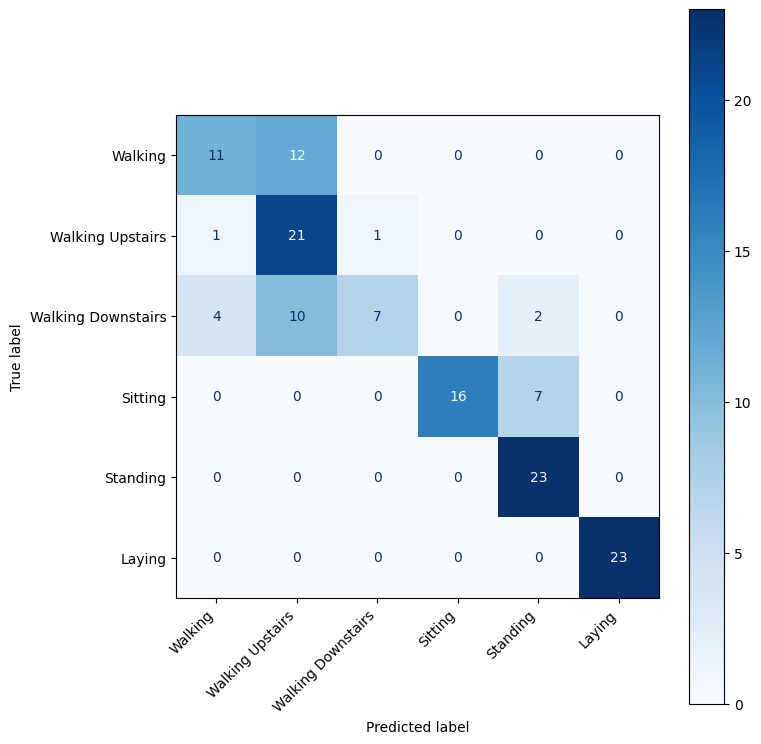

In [11]:
cm = confusion_matrix(y_test_my, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Walking",
        "Walking Upstairs",
        "Walking Downstairs",
        "Sitting",
        "Standing",
        "Laying"
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()